In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
from shapely.geometry import box, Polygon
import rasterio
from sklearn.model_selection import train_test_split
import os


In [43]:
def split_train_test(crowns, contour, outfolder, patch_size_m = 25, n_trees_minimum = 10, val_size = 0.10, test_size=0.10, random_state=42):
    """
    Function `split_train_test` takes the following inputs:
    - `crowns` (GeoDataFrame): Polygons representing tree crowns.
    - `contour` (GeoDataFrame): Contours of the area of interest (plantation).
    - `outfolder` (str): Path to the folder where output shapefiles will be saved.
    - `patch_size_m` (float, optional): Size of the square patches in meters. Default is 25.
    - `n_trees_minimum` (int, optional): Minimum number of crowns required to create a square. Default is 15.
    - `test_size` (float, optional): Proportion of the dataset to include in the test split. Default is 0.2.
    - `random_state` (int, optional): Random seed for reproducibility. Default is 42.

    Outputs:
    - `train_squares` (GeoDataFrame): GeoDataFrame containing the training set polygons.
    - `test_squares` (GeoDataFrame): GeoDataFrame containing the test set polygons.

    Steps:
    1. Ensures the output folder exists.
    2. Computes the bounding box of `crowns` and generates a grid of square polygons of fixed size (`patch_size_m`).
    3. Filters squares to retain only those intersecting at least 10 polygons from `crowns`.
    4. Clips the squares with `contour` to ensure they remain within the area of interest.
    5. Splits the resulting squares into training and test sets based on `test_size`.
    6. Saves the training and test sets as shapefiles in the specified `outfolder`.
    7. Returns the training and test GeoDataFrames.
    """
 
    if not os.path.exists(outfolder):
        os.makedirs(outfolder)

    # Créer un nouveau GeoDataFrame pour stocker les polygones carrés qui vont être crées
    squares_gdf = gpd.GeoDataFrame(columns=['geometry'], crs=crowns.crs)

    # Trouver les limites du shapefile crowns
    minx, miny, maxx, maxy = crowns.total_bounds
    # print(f"Bounds: {minx}, {miny}, {maxx}, {maxy}")

    # Calculer le nombre de carrés nécessaires dans les directions x et y    
    num_squares_x = int((maxx - minx) / patch_size_m) + 1
    num_squares_y = int((maxy - miny) / patch_size_m) + 1

    # Créer ces polygones, mais seulement ceux qui contiennent au moins un polygone original
    for i in range(num_squares_x):
        for j in range(num_squares_y):
            square = box(minx + i * patch_size_m, miny + j * patch_size_m, minx + (i + 1) * patch_size_m, miny + (j + 1) * patch_size_m)
        
            # Vérifier si le carré intersecte au moins n_trees_minimum polygones de crowns
            if crowns.intersects(square).sum() >= n_trees_minimum:
                squares_gdf = pd.concat([squares_gdf, gpd.GeoDataFrame({'geometry': [square]}, crs=crowns.crs)], ignore_index=True)
    
    #s'assurer que le contour et les carrés ont la même projection
    contour = contour.to_crs(squares_gdf.crs)

    # Découper les carrés avec le contour
    squares_gdf = gpd.overlay(squares_gdf, contour, how='intersection')

    # split traintest
    test_percent = test_size
    val_percent = val_size
    train_percent = 1 - val_percent - test_percent
    
    # Split the squares into train and test sets
    trainval_squares, test_squares = train_test_split(squares_gdf, test_size=test_percent, random_state=random_state)
    train_squares, val_squares = train_test_split(trainval_squares, test_size=val_percent/(train_percent+val_percent), random_state=random_state) 

    num_train_squares = len(train_squares)
    num_val_squares = len(val_squares)
    num_test_squares = len(test_squares)

    print(f"Nombre total de carrés: {len(squares_gdf)}")
    print(f"Nombre de carrés d'entraînement: {num_train_squares}")
    print(f"Nombre de carrés de val: {num_val_squares}")
    print(f"Nombre de carrés de test: {num_test_squares}")

    # Regrouper tous les polygones de train_squares en un seul polygone multipart
    train_squares = gpd.GeoDataFrame(geometry=[train_squares.geometry.union_all()], crs=train_squares.crs)
    val_squares = gpd.GeoDataFrame(geometry=[val_squares.geometry.union_all()], crs=test_squares.crs)
    test_squares = gpd.GeoDataFrame(geometry=[test_squares.geometry.union_all()], crs=test_squares.crs)

    #Calculer le nombre de carrés et l'aire totale dans chaque ensemble
    train_area = train_squares.geometry.area.sum()
    val_area = val_squares.geometry.area.sum()
    test_area = test_squares.geometry.area.sum()
    print(f"Aire totale des carrés d'entraînement: {train_area:.2f} m²")    
    print(f"Aire totale des carrés en val: {val_area:.2f} m²")
    print(f"Aire totale des carrés en test: {test_area:.2f} m² ")
    print(f"Proportion de la surface en val: {val_area/(train_area+val_area+test_area):.2f}")
    print(f"Proportion de la surface en test: {test_area/(train_area+val_area+test_area):.2f}")


    # Enregistrer les GeoDataFrames dans trois fichiers shapefile distincts
    train_squares.to_file(os.path.join(outfolder, 'train_areas.shp'), driver='ESRI Shapefile')
    val_squares.to_file(os.path.join(outfolder, 'val_areas.shp'), driver='ESRI Shapefile')
    test_squares.to_file(os.path.join(outfolder, 'test_areas.shp'), driver='ESRI Shapefile')

    #combiner les trois GeoDataFrames en un seul shapefile
    combined = pd.concat([train_squares, val_squares, test_squares], ignore_index=True)
    combined.to_file(os.path.join(outfolder, 'example_rectangle.shp'), driver='ESRI Shapefile')

    #dans le shapefile combine, unir les polygones en un seul
    combined = gpd.GeoDataFrame(geometry=[combined.geometry.union_all()], crs=combined.crs)
    combined.to_file(os.path.join(outfolder, 'example_rectangle_one_polygon.shp'), driver='ESRI Shapefile')

    print("Nouveau shapefiles 'train_areas.shp', 'val_areas.shp', 'test_areas.shp' créé avec succès.")
    print("Le shapefile 'example_rectangle' contient les trois polygones ensemble.")
    print(f"outfiles: {os.path.join(outfolder, 'train_areas.shp')}, {os.path.join(outfolder, 'test_areas.shp')}")

    return train_squares, val_squares, test_squares

def viz_train_val_test_areas (tif_path, crowns, train, val, test, outfile_path, buffer=10, alpha_tif=0.6):    
    fig, ax = plt.subplots(figsize=(10, 10))

    # Ouvrir le raster
    with rasterio.open(tif_path) as src:
        img = src.read(1)
        img = np.where(img == 0, np.nan, img)
        img = np.clip(img, 0, 255)
        bounds = src.bounds

        # Conversion CRS
        train = train.to_crs(src.crs)
        val = val.to_crs(src.crs)
        test = test.to_crs(src.crs)
        crowns = crowns.to_crs(src.crs)

    # Plot du raster avec **son propre extent**
    ax.imshow(img, cmap='gray',
            extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
            alpha=alpha_tif, origin='upper', zorder=0)

    # Plot des couches vectorielles
    train.plot(ax=ax, color='green', zorder=3)
    val.plot(ax=ax, color='blue', zorder=3)
    test.plot(ax=ax, color='yellow', zorder=3)
    crowns.plot(ax=ax, color='red', zorder=3)

    # Définir les limites d’affichage (zoom) sur les GPD + buffer
    all_bounds = np.array([
        train.total_bounds,
        val.total_bounds,
        test.total_bounds
    ])
    minx = all_bounds[:, 0].min() - buffer
    miny = all_bounds[:, 1].min() - buffer
    maxx = all_bounds[:, 2].max() + buffer
    maxy = all_bounds[:, 3].max() + buffer

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    # Ajouter une légende personnalisée avec fond semi-transparent
    legend_elements = [
        Patch(facecolor='green', edgecolor='black', label='Train'),
        Patch(facecolor='blue', edgecolor='black', label='Validation'),
        Patch(facecolor='yellow', edgecolor='black', label='Test'),
        Patch(facecolor='red', edgecolor='black', label='Couronnes')
    ]
    legend = ax.legend(handles=legend_elements, loc='upper right', title='Données', frameon=True)
    legend.get_frame().set_alpha(0.8)  # Fond semi-transparent
    legend.get_frame().set_facecolor('white')

    # Titre et affichage
    ax.set_title("Train, Validation, Test et Couronnes")
    plt.tight_layout()
    plt.savefig(outfile_path, dpi=300, bbox_inches='tight')
    plt.show()



## Cw_JR_East

Nombre total de carrés: 35
Nombre de carrés d'entraînement: 27
Nombre de carrés de val: 4
Nombre de carrés de test: 4
Aire totale des carrés d'entraînement: 14396.43 m²
Aire totale des carrés en val: 1901.08 m²
Aire totale des carrés en test: 1684.89 m² 
Proportion de la surface en val: 0.11
Proportion de la surface en test: 0.09
Nouveau shapefiles 'train_areas.shp', 'val_areas.shp', 'test_areas.shp' créé avec succès.
Le shapefile 'example_rectangle' contient les trois polygones ensemble.
outfiles: C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp, C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\test_areas.shp


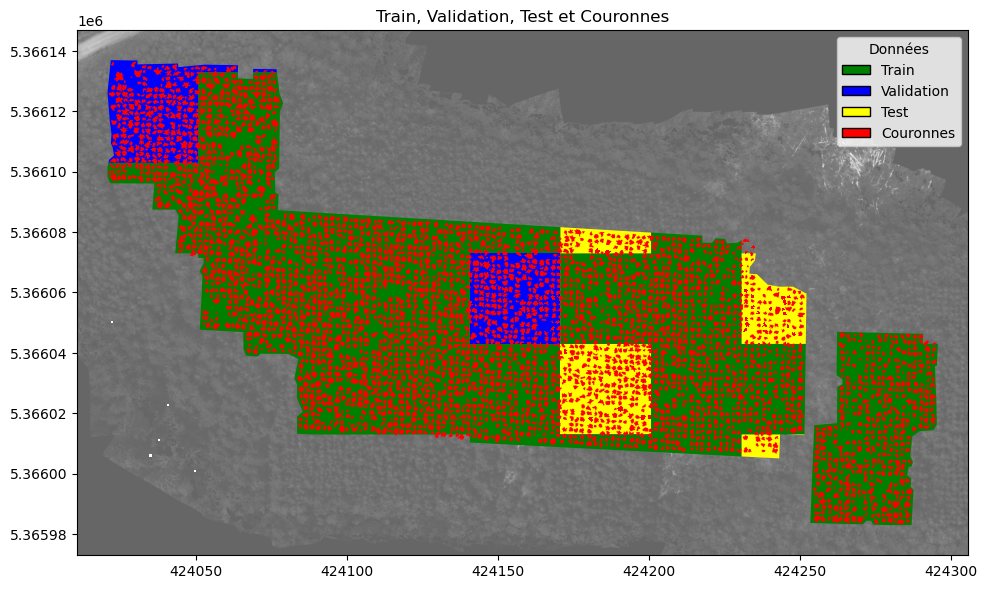

In [44]:
crowns = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\Crowns_clean\Cw_JR_East_crowns_clean_v2.shp')
contour = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\Contour\Cw_JR_East_Contour.shp')
outfolder = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split'
train, val, test = split_train_test(crowns, contour, outfolder, patch_size_m = 30, val_size = 0.10,  test_size=0.10, random_state=39)

#plot train, val, test
tif_path = 'C:/Users/sinadeau/OneDrive - NRCan RNCan/data_glo7030-projet/Cw_JR_East/MS_2023_05_08/Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2.tif'
outfile_path = 'C:/Users/sinadeau/OneDrive - NRCan RNCan/data_glo7030-projet/Cw_JR_East/train_test_split/train_val_test.png'
viz_train_val_test_areas (tif_path, crowns, train, val, test, outfile_path)

## Cw_JR_Sandcut

Nombre total de carrés: 25
Nombre de carrés d'entraînement: 19
Nombre de carrés de val: 3
Nombre de carrés de test: 3
Aire totale des carrés d'entraînement: 12111.52 m²
Aire totale des carrés en val: 1853.71 m²
Aire totale des carrés en test: 1358.29 m² 
Proportion de la surface en val: 0.12
Proportion de la surface en test: 0.09
Nouveau shapefiles 'train_areas.shp', 'val_areas.shp', 'test_areas.shp' créé avec succès.
Le shapefile 'example_rectangle' contient les trois polygones ensemble.
outfiles: C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp, C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\test_areas.shp


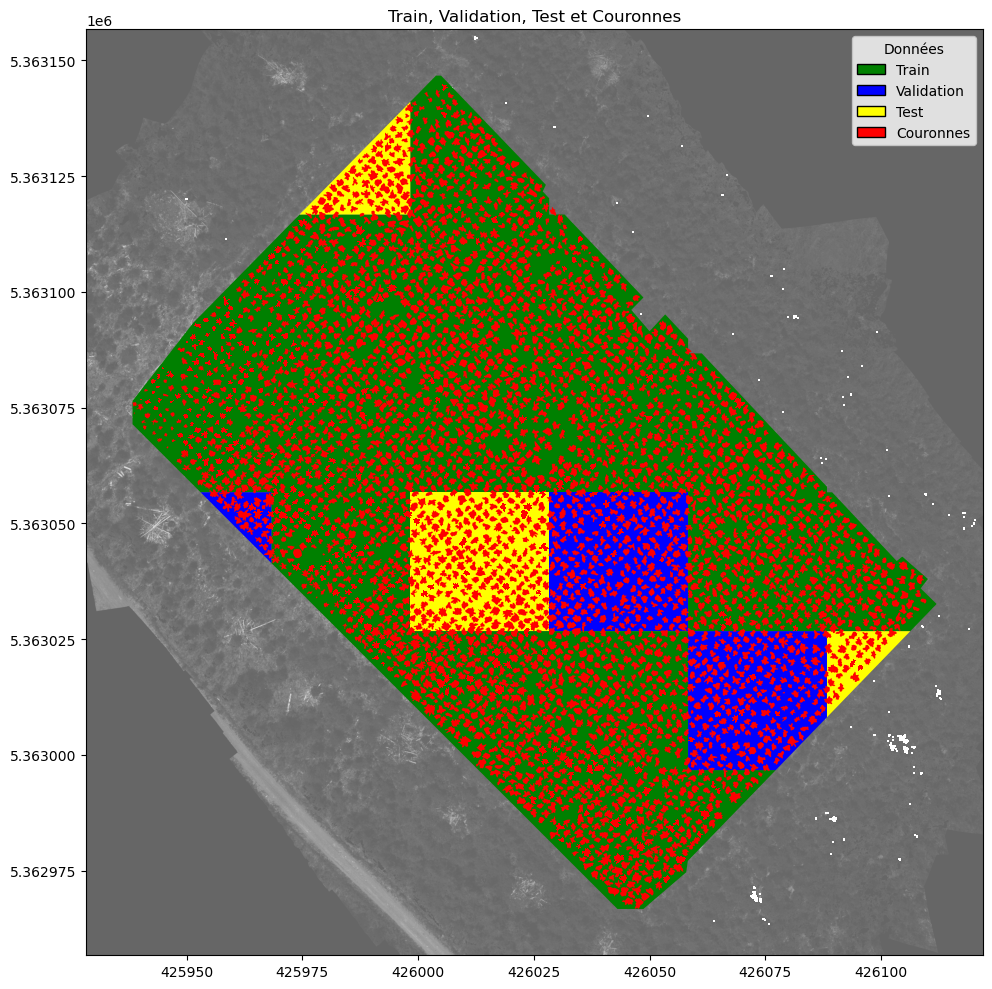

In [52]:
crowns = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\Crowns_clean\Cw_JR_Sandcut_crowns_clean_v2.shp')
contour = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\Contour\Cw_JR_Sandcut_Contour.shp')
outfolder = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split'
train, val, test = split_train_test(crowns, contour, outfolder, patch_size_m = 30, val_size = 0.10,  test_size=0.10, random_state=51)

#plot train, val, test
tif_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\MS_2022_05_25\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001.tif'
outfile_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_val_test.png'
viz_train_val_test_areas (tif_path, crowns, train, val, test, outfile_path)

## Cw_PR_Rainbow_SiteA

Nombre total de carrés: 19
Nombre de carrés d'entraînement: 15
Nombre de carrés de val: 2
Nombre de carrés de test: 2
Aire totale des carrés d'entraînement: 7615.42 m²
Aire totale des carrés en val: 1130.57 m²
Aire totale des carrés en test: 1477.06 m² 
Proportion de la surface en val: 0.11
Proportion de la surface en test: 0.14
Nouveau shapefiles 'train_areas.shp', 'val_areas.shp', 'test_areas.shp' créé avec succès.
Le shapefile 'example_rectangle' contient les trois polygones ensemble.
outfiles: C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp, C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\test_areas.shp


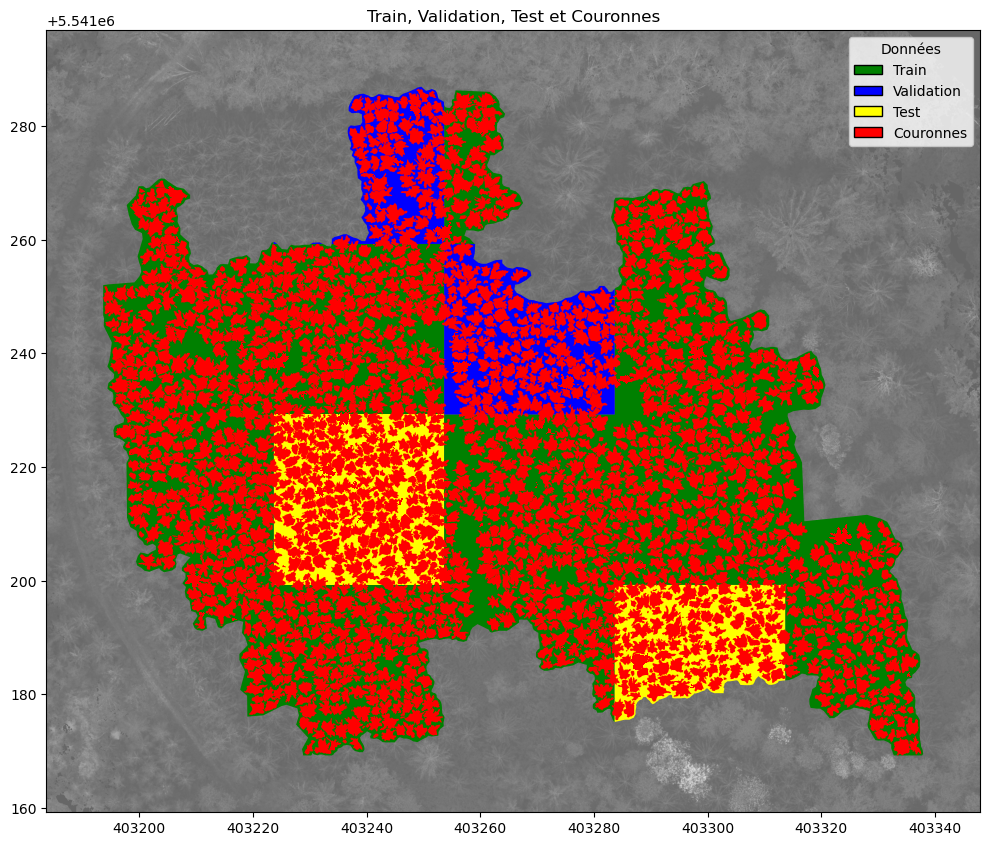

In [53]:
crowns = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\Crowns_clean\Cw_PR_Rainbow_SiteA_crowns_clean_v2.shp')
contour = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\Contour\Cw_PR_Rainbow_siteA_contour.shp')
outfolder = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split'
train, val, test = split_train_test(crowns, contour, outfolder, patch_size_m = 30, val_size = 0.10,  test_size=0.10, random_state=39)

#plot train, val, test
tif_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\MS_2022_05_26\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel.tif'
outfile_path =r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_val_test.png'
viz_train_val_test_areas (tif_path, crowns, train, val, test, outfile_path)

## Cw_PR_Rainbow_SiteB

Nombre total de carrés: 14
Nombre de carrés d'entraînement: 10
Nombre de carrés de val: 2
Nombre de carrés de test: 2
Aire totale des carrés d'entraînement: 4976.02 m²
Aire totale des carrés en val: 1073.73 m²
Aire totale des carrés en test: 1148.80 m² 
Proportion de la surface en val: 0.15
Proportion de la surface en test: 0.16
Nouveau shapefiles 'train_areas.shp', 'val_areas.shp', 'test_areas.shp' créé avec succès.
Le shapefile 'example_rectangle' contient les trois polygones ensemble.
outfiles: C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp, C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\test_areas.shp


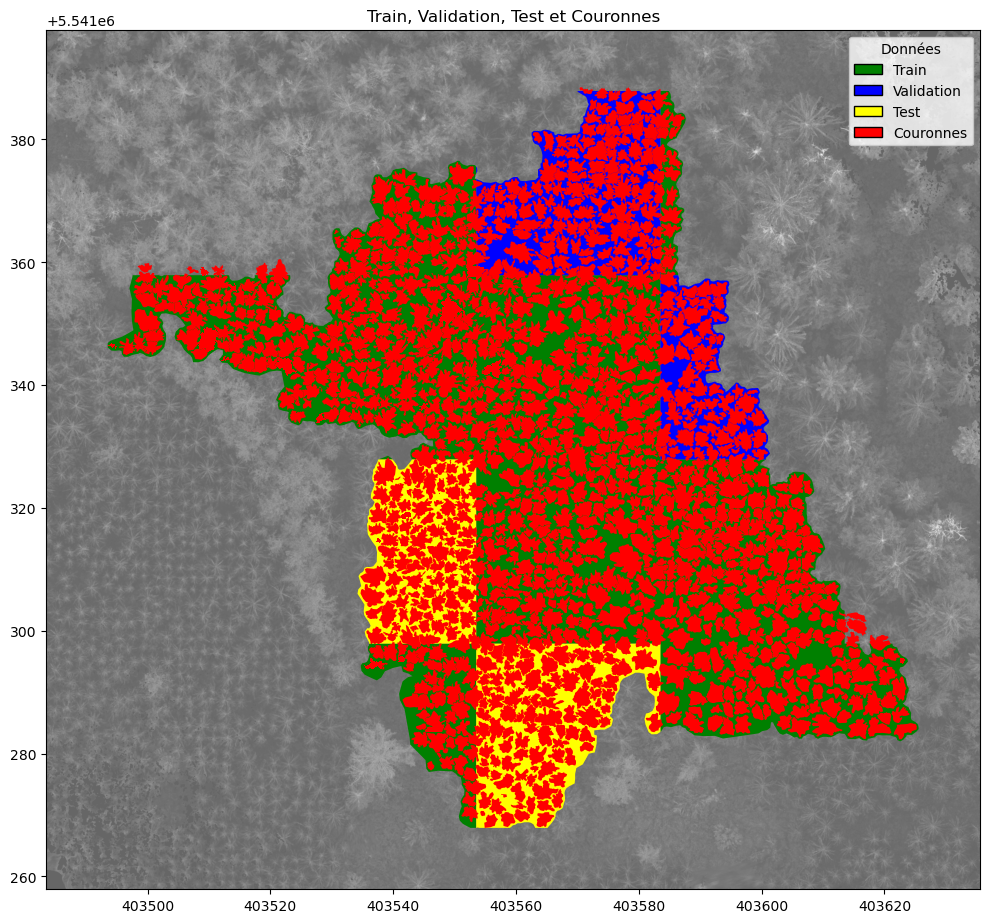

In [54]:
crowns = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\Crowns_clean\Cw_PR_Rainbow_SiteB_crowns_clean_v2.shp')
contour = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\Contour\Cw_PR_Rainbow_siteB_Contour.shp')
outfolder = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split'
train, val, test = split_train_test(crowns, contour, outfolder, patch_size_m = 30, val_size = 0.10,  test_size=0.10, random_state=39)

#plot train, val, test
tif_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\MS_2022_05_26\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel.tif'
outfile_path =r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_val_test.png'
viz_train_val_test_areas (tif_path, crowns, train, val, test, outfile_path)

## Fdc_JR_East_GCA

Nombre total de carrés: 20
Nombre de carrés d'entraînement: 16
Nombre de carrés de val: 2
Nombre de carrés de test: 2
Aire totale des carrés d'entraînement: 8563.95 m²
Aire totale des carrés en val: 1781.59 m²
Aire totale des carrés en test: 1623.80 m² 
Proportion de la surface en val: 0.15
Proportion de la surface en test: 0.14
Nouveau shapefiles 'train_areas.shp', 'val_areas.shp', 'test_areas.shp' créé avec succès.
Le shapefile 'example_rectangle' contient les trois polygones ensemble.
outfiles: C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp, C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\test_areas.shp


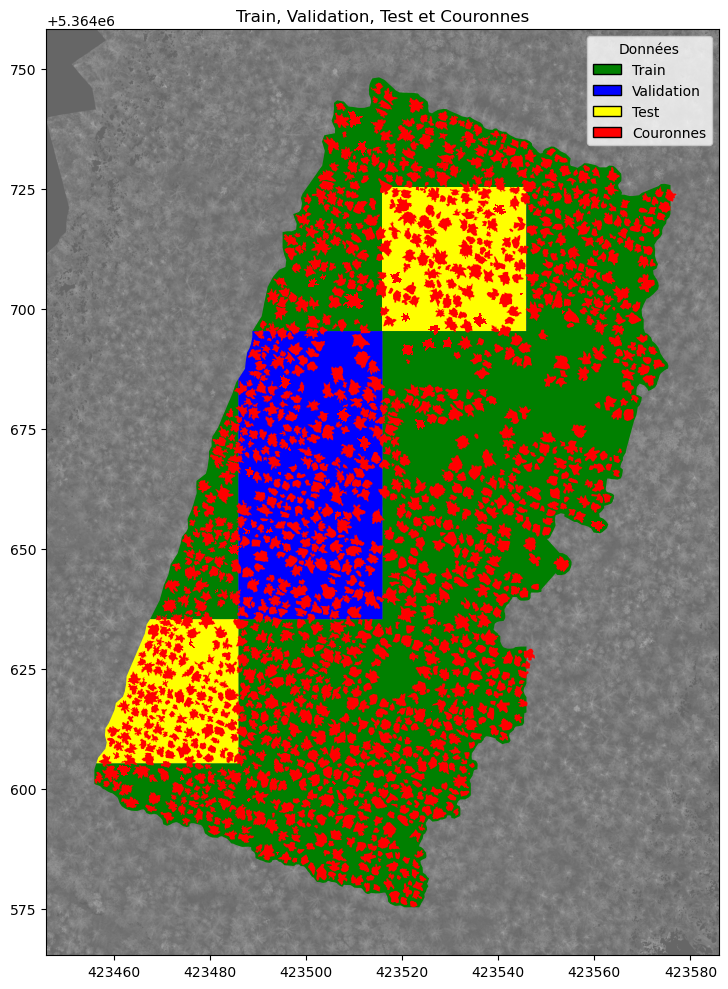

In [62]:
crowns = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\Crowns_clean\Fdc_JR_East_GCA_crowns_clean_v2.shp')
contour = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\Contour\Fdc_JR_East_GCA_Contour_v2.shp')
outfolder = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split'
train, val, test = split_train_test(crowns, contour, outfolder, patch_size_m = 30, val_size = 0.10,  test_size=0.10, random_state=37)

#plot train, val, test
tif_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\MS_2022_05_24\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2.tif'
outfile_path =r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_val_test.png'
viz_train_val_test_areas (tif_path, crowns, train, val, test, outfile_path)

## Fdc_JR_W45

Nombre total de carrés: 18
Nombre de carrés d'entraînement: 14
Nombre de carrés de val: 2
Nombre de carrés de test: 2
Aire totale des carrés d'entraînement: 7320.99 m²
Aire totale des carrés en val: 1207.33 m²
Aire totale des carrés en test: 1180.00 m² 
Proportion de la surface en val: 0.12
Proportion de la surface en test: 0.12
Nouveau shapefiles 'train_areas.shp', 'val_areas.shp', 'test_areas.shp' créé avec succès.
Le shapefile 'example_rectangle' contient les trois polygones ensemble.
outfiles: C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp, C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\test_areas.shp


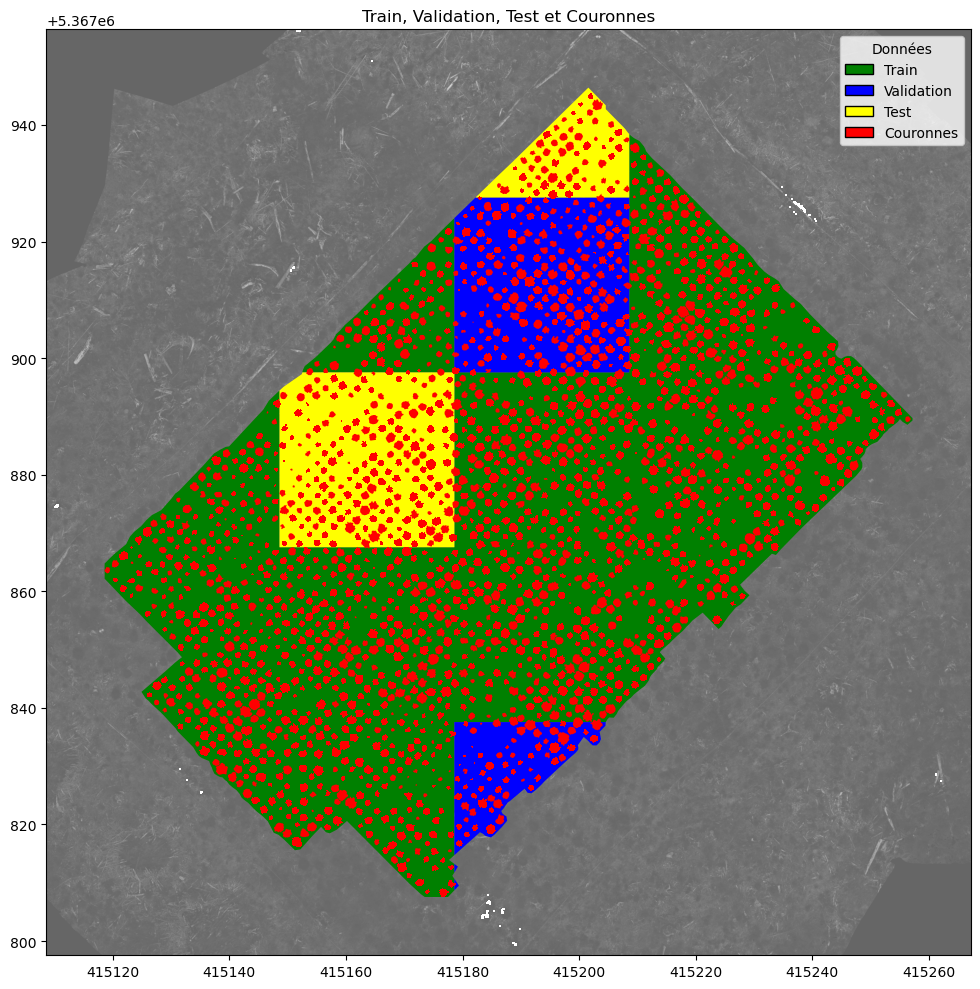

In [65]:
crowns = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\Crowns_clean\Fdc_JR_W45_crowns_clean_v2.shp')
contour = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\Contour\Fdc_JR_W45_2023_contour_precis.shp')
outfolder = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split'
train, val, test = split_train_test(crowns, contour, outfolder, patch_size_m = 30, val_size = 0.10,  test_size=0.10, random_state=39)

#plot train, val, test
tif_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\MS_2023_03_21\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001.tif'
outfile_path =r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_val_test.png'
viz_train_val_test_areas (tif_path, crowns, train, val, test, outfile_path)

## Fdc_PR_Canoe

Nombre total de carrés: 33
Nombre de carrés d'entraînement: 25
Nombre de carrés de val: 4
Nombre de carrés de test: 4
Aire totale des carrés d'entraînement: 15723.43 m²
Aire totale des carrés en val: 2936.07 m²
Aire totale des carrés en test: 2299.68 m² 
Proportion de la surface en val: 0.14
Proportion de la surface en test: 0.11
Nouveau shapefiles 'train_areas.shp', 'val_areas.shp', 'test_areas.shp' créé avec succès.
Le shapefile 'example_rectangle' contient les trois polygones ensemble.
outfiles: C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp, C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\test_areas.shp


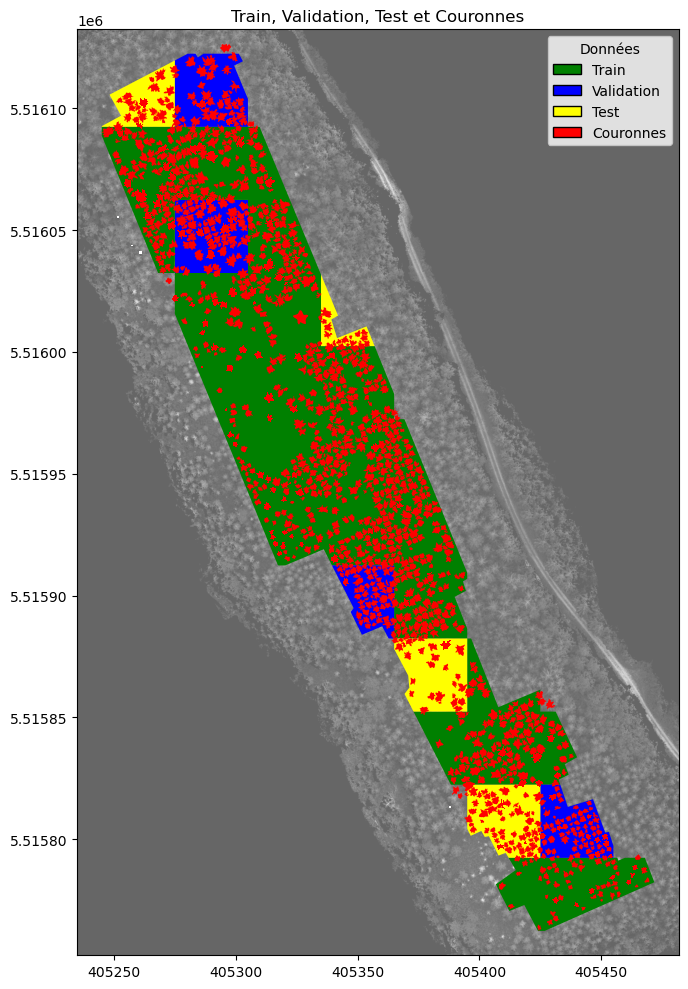

In [66]:
crowns = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\Crowns_clean\Fdc_PR_Canoe_crowns_clean_v2.shp')
contour = gpd.read_file(r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\Contour\Fdc_PR_Canoe_contour_EPSG26910.shp')
outfolder = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split'
train, val, test = split_train_test(crowns, contour, outfolder, patch_size_m = 30, val_size = 0.10,  test_size=0.10, random_state=39)

#plot train, val, test
tif_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\MS_2022_06_08\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001.tif'
outfile_path =r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_val_test.png'
viz_train_val_test_areas (tif_path, crowns, train, val, test, outfile_path)